# Sequence evolution and variant fitness in Covasim

This notebook demonstrates two linked features:

1. **Sequence evolution** — Each transmission accumulates nucleotide mutations sampled from a Jukes-Cantor (JC69) model. `infection_log` entries carry `branch_length`, `branch_mutations`, and `n_mutations`; full haplotypes are reconstructed on demand via `sequence_tracker.reconstruct_haplotype()`.

2. **Variant fitness** — `BloomNtFitnessModel` (Bloom lab `nt_fitness.csv`) maps each haplotype's accumulated mutations to a log-fitness score and multiplies the agent's transmissibility by `exp(Σ fitness_i × scale)`. Fitter haplotypes spread faster with no manual `rel_beta` tuning required.

**Requirements:**
- `NC_045512_Hu-1.fasta` — Wuhan-1 reference genome (29 903 nt)
- `data/nt_fitness.csv` — Bloom lab nucleotide fitness table
- `ARTIC_V4-1.bed` — primer BED for wastewater read simulation (Part 4)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import covasim as cv

Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM


## Part 1: Basic sequence evolution

The minimal config is `seq_pars['enable'] = True` plus a reference FASTA. The JC69 model draws `Poisson(L × μ × Δt)` substitutions per transmission edge, where `Δt` is the gap in days between source and target exposure.

In [2]:
sim1 = cv.Sim(dict(
    pop_size             = 50_000,
    pop_infected         = 1,
    start_day            = '2020-01-01',
    end_day              = '2020-06-01',
    seq_pars = dict(
        enable                = True,
        reference             = 'NC_045512_Hu-1.fasta',
        mol_clock_rate = 1e-6,   # ~1 substitution/genome/month at 30 000 nt
        model                 = 'JC',
    ),
))
sim1.run()

Initializing sim with 50000 people for 152 days
  Running 2020-01-01 ( 0/152) (0.12 s)  ———————————————————— 1%
  Running 2020-01-11 (10/152) (0.16 s)  •——————————————————— 7%
  Running 2020-01-21 (20/152) (0.19 s)  ••—————————————————— 14%
  Running 2020-01-31 (30/152) (0.23 s)  ••••———————————————— 20%
  Running 2020-02-10 (40/152) (0.26 s)  •••••——————————————— 27%
  Running 2020-02-20 (50/152) (0.30 s)  ••••••—————————————— 33%
  Running 2020-03-01 (60/152) (0.34 s)  •••••••————————————— 40%
  Running 2020-03-11 (70/152) (0.38 s)  •••••••••——————————— 46%
  Running 2020-03-21 (80/152) (0.43 s)  ••••••••••—————————— 53%
  Running 2020-03-31 (90/152) (0.56 s)  •••••••••••————————— 59%
  Running 2020-04-10 (100/152) (0.71 s)  •••••••••••••——————— 66%
  Running 2020-04-20 (110/152) (0.96 s)  ••••••••••••••—————— 73%
  Running 2020-04-30 (120/152) (1.24 s)  •••••••••••••••————— 79%
  Running 2020-05-10 (130/152) (1.42 s)  •••••••••••••••••——— 86%
  Running 2020-05-20 (140/152) (1.54 s) 

Sim(<no label>; 2020-01-01 to 2020-06-01; pop: 50000 random; epi: 52271⚙, 305☠)

In [3]:
log    = sim1.people.infection_log
n_muts = [e['n_mutations'] for e in log if 'n_mutations' in e]

print(f'Transmission events:    {len(log):,}')
print(f'Mean branch mutations:  {np.mean(n_muts):.3f}')
print(f'Max branch mutations:   {max(n_muts)}')

Transmission events:    52,271
Mean branch mutations:  0.233
Max branch mutations:   5


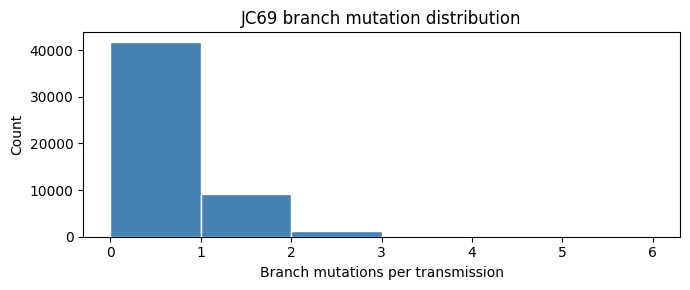

In [4]:
# Distribution of branch mutations across all transmission edges
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(n_muts, bins=range(max(n_muts) + 2), color='steelblue', edgecolor='white')
ax.set_xlabel('Branch mutations per transmission')
ax.set_ylabel('Count')
ax.set_title('JC69 branch mutation distribution')
plt.tight_layout()
plt.show()

In [5]:
# Reconstruct haplotypes for the first few agents and count divergence from reference
tracker = sim1.sequence_tracker
ref_seq = cv.decode_sequence(tracker.reference)

sample_agents = [int(e['target']) for e in log[:5]]
for agent in sample_agents:
    hap   = tracker.reconstruct_haplotype(agent)
    ndiff = sum(a != b for a, b in zip(hap, ref_seq))
    print(f'  Agent {agent:6d}: {ndiff} mutation(s) vs reference')

  Agent  26247: 0 mutation(s) vs reference
  Agent   2042: 4 mutation(s) vs reference
  Agent  42096: 5 mutation(s) vs reference
  Agent  12643: 2 mutation(s) vs reference
  Agent  39481: 5 mutation(s) vs reference


## Part 2: Fitness-weighted sequence evolution

`BloomNtFitnessModel` looks up each mutation in the Bloom lab table and computes:

$$\text{rel\_beta} \leftarrow \exp\!\left(\sum_i \text{fitness}_i \times \text{scale}\right)$$

Beneficial mutations (positive log-fitness) propagate faster; deleterious ones are suppressed — driven entirely by empirical data, not hand-tuned parameters.

In [ ]:
sim2 = cv.Sim(dict(
    pop_size             = 50_000,
    pop_infected         = 1,
    start_day            = '2020-01-01',
    end_day              = '2020-06-01',
    seq_pars = dict(
        enable                = True,
        reference             = 'NC_045512_Hu-1.fasta',
        mol_clock_rate = 1e-6,
        model                 = 'JC',
    ),
    fitness_pars = dict(
        enable       = True,
        model        = 'bloom_nt',
        fitness_data_path = 'data/nt_fitness.csv',
        scale        = 0.1,   # tune to calibrate how strongly fitness shapes sweeps
    ),
))
sim2.run()

Initializing sim with 50000 people for 152 days
  Running 2020-01-01 ( 0/152) (0.27 s)  ———————————————————— 1%
  Running 2020-01-11 (10/152) (0.31 s)  •——————————————————— 7%
  Running 2020-01-21 (20/152) (0.34 s)  ••—————————————————— 14%
  Running 2020-01-31 (30/152) (0.38 s)  ••••———————————————— 20%
  Running 2020-02-10 (40/152) (0.41 s)  •••••——————————————— 27%
  Running 2020-02-20 (50/152) (0.45 s)  ••••••—————————————— 33%
  Running 2020-03-01 (60/152) (0.48 s)  •••••••————————————— 40%
  Running 2020-03-11 (70/152) (0.52 s)  •••••••••——————————— 46%
  Running 2020-03-21 (80/152) (0.56 s)  ••••••••••—————————— 53%
  Running 2020-03-31 (90/152) (0.60 s)  •••••••••••————————— 59%
  Running 2020-04-10 (100/152) (0.65 s)  •••••••••••••——————— 66%
  Running 2020-04-20 (110/152) (0.72 s)  ••••••••••••••—————— 73%
  Running 2020-04-30 (120/152) (0.84 s)  •••••••••••••••————— 79%
  Running 2020-05-10 (130/152) (1.11 s)  •••••••••••••••••——— 86%
  Running 2020-05-20 (140/152) (1.39 s) 

Sim(<no label>; 2020-01-01 to 2020-06-01; pop: 50000 random; epi: 39498⚙, 122☠)

In [7]:
tracker2    = sim2.sequence_tracker
all_agents  = [int(e['target']) for e in sim2.people.infection_log]
multipliers = [tracker2.get_fitness_multiplier(a) for a in all_agents]

print(f'Mean fitness multiplier:   {np.mean(multipliers):.4f}')
print(f'Max fitness multiplier:    {max(multipliers):.4f}')
print(f'Agents with rel_beta > 1:  {sum(m > 1.0 for m in multipliers):,}')

Mean fitness multiplier:   0.8750
Max fitness multiplier:    1.5159
Agents with rel_beta > 1:  12,671


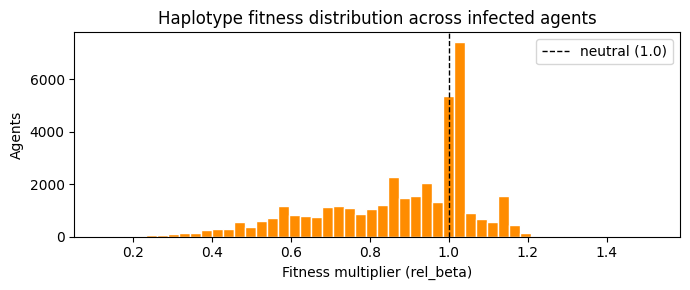

In [8]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(multipliers, bins=50, color='darkorange', edgecolor='white')
ax.axvline(1.0, color='black', linestyle='--', linewidth=1, label='neutral (1.0)')
ax.set_xlabel('Fitness multiplier (rel_beta)')
ax.set_ylabel('Agents')
ax.set_title('Haplotype fitness distribution across infected agents')
ax.legend()
plt.tight_layout()
plt.show()

## Part 3: Variant competition with a founding genotype

When `cv.variant()` is given a `founding_fasta`, the tracker loads that consensus sequence, diffs it against the reference, and seeds every import of that variant with its characteristic mutation profile. Subsequent evolution accumulates on top.

Here ay1 arrives on day 20. Its `rel_beta` gives an intrinsic transmission advantage; the Bloom fitness scores from its founding mutations further shape the competition.

In [ ]:
ay1 = cv.variant(
    variant = {},
    label     = 'AY.1',
    days      = 20,
    n_imports = 30,
    founding_fasta = 'ay1_consensus.fasta',
)

sim3 = cv.Sim(
    dict(
        pop_size     = 50_000,
        pop_infected = 20,
        start_day    = '2022-10-01',
        end_day      = '2023-04-01',
        seq_pars = dict(
            enable                = True,
            reference             = 'NC_045512_Hu-1.fasta',
            mol_clock_rate = 1e-6,
            model                 = 'JC',
        ),
        fitness_pars = dict(
            enable       = True,
            model        = 'bloom_nt',
            fitness_data_path = 'data/nt_fitness.csv',
            scale        = 0.1,
        ),
    ),
    variants  = [ay1],
    analyzers = [cv.WastewaterSampler(days=list(range(0, 180, 14)))],
)
sim3.run()

Initializing sim with 50000 people for 182 days
  Running 2022-10-01 ( 0/182) (0.29 s)  ———————————————————— 1%
  Running 2022-10-11 (10/182) (0.34 s)  •——————————————————— 6%
  Running 2022-10-21 (20/182) (0.55 s)  ••—————————————————— 11%
  Running 2022-10-31 (30/182) (1.71 s)  •••————————————————— 17%
  Running 2022-11-10 (40/182) (1.85 s)  ••••———————————————— 22%
  Running 2022-11-20 (50/182) (9.28 s)  •••••——————————————— 28%
  Running 2022-11-30 (60/182) (42.96 s)  ••••••—————————————— 33%
  Running 2022-12-10 (70/182) (43.94 s)  •••••••————————————— 39%
  Running 2022-12-20 (80/182) (81.97 s)  ••••••••———————————— 44%
  Running 2022-12-30 (90/182) (95.99 s)  •••••••••——————————— 50%
  Running 2023-01-09 (100/182) (100.71 s)  •••••••••••————————— 55%
  Running 2023-01-19 (110/182) (100.84 s)  ••••••••••••———————— 61%
  Running 2023-01-29 (120/182) (102.69 s)  •••••••••••••——————— 66%
  Running 2023-02-08 (130/182) (103.55 s)  ••••••••••••••—————— 72%
  Running 2023-02-18 (140/18

Sim(<no label>; 2022-10-01 to 2023-04-01; pop: 50000 random; epi: 65482⚙, 303☠)

In [10]:
# Cumulative infections by variant (rows: 0 = wild-type, 1 = AY.1)
cumulative = sim3.results['variant']['cum_infections_by_variant']
print(f'Wild-type cumulative infections:  {int(cumulative[0, -1]):,}')
print(f'AY.1 cumulative infections:    {int(cumulative[1, -1]):,}')

Wild-type cumulative infections:  15,036
AY.1 cumulative infections:    50,466


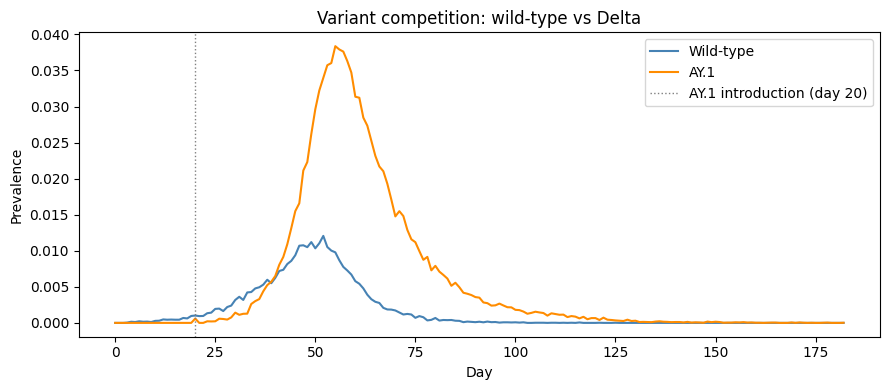

In [11]:
# Variant prevalence over time
prev = sim3.results['variant']['prevalence_by_variant']
tvec = sim3.results['t']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tvec, prev[0], label='Wild-type', color='steelblue')
ax.plot(tvec, prev[1], label='AY.1',   color='darkorange')
ax.axvline(20, color='gray', linestyle=':', linewidth=1, label='AY.1 introduction (day 20)')
ax.set_xlabel('Day')
ax.set_ylabel('Prevalence')
ax.set_title('Variant competition: wild-type vs Delta')
ax.legend()
plt.tight_layout()
plt.show()

## Part 4: Wastewater FASTA output

`WastewaterSampler` records which agents are infected at each requested day and their reconstructed haplotypes. `to_fasta(day)` returns a multi-sequence FASTA ready for consensus-calling pipelines. `simulate_sample()` feeds that into `bygul` to produce amplicon reads for testing bioinformatic tools.

> **Gotcha:** always use `sim.get_analyzer('WastewaterSampler')`, not `sim.analyzers[i]`. The latter returns a deep copy made at initialization and will have no sampled data.

In [12]:
ww  = sim3.get_analyzer('WastewaterSampler')
day = 56
print(list(range(0, 180, 14)))

fasta_text = ww.to_fasta(day)
n_seqs     = fasta_text.count('>')
print(f'Day {day}: {n_seqs} sequences')

with open('day56.fasta', 'w') as f:
    f.write(fasta_text)
print('Written: day56.fasta')

# Preview the first sequence header and a snippet of its bases
lines = fasta_text.splitlines()
print(lines[0])          # header
print(lines[1][:80], '...')  # first 80 nt

[0, 14, 28, 42, 56, 70, 84, 98, 112, 126, 140, 154, 168]
Day 56: 2974 sequences
Written: day56.fasta
>genotype_0  proportion=0.45813018  day=56  date=2022-11-26
ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTCGATCTCTTGTAGATCTGTTCTCTAAACGAACTTTAA ...


In [13]:
# # Uncomment to generate synthetic amplicon reads (requires wgsim on PATH):
# ww.simulate_sample(
#     day       = 28,
#     primers   = 'ARTIC_V4-1.bed',
#     reference = 'NC_045512_Hu-1.fasta',
#     outdir    = './reads/',
#     redo      = True,
#     simulator = 'wgsim',
# )